# Presentation Graphics — MS&E 108

**Purpose:** Generate all figures, tables, and metrics for the project presentation.

Run cells in order; figures are saved to `../figures/` with slide-numbered filenames.

In [30]:
import sys, os, glob
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import stats as sp_stats

from src.as_detector import run_as_detection, run_all_tickers, ASResult
from src.mm_backtest import compare_all_tickers, analyse_fill_toxicity

FIGDIR = os.path.join('..', 'figures')
os.makedirs(FIGDIR, exist_ok=True)
print(f"Figures will be saved to {FIGDIR}")

Figures will be saved to ../figures


## Slide 3: The "Insider" Problem — Diagram

Flowchart: Insider → big bet → outcome revealed → insider wins, market maker loses

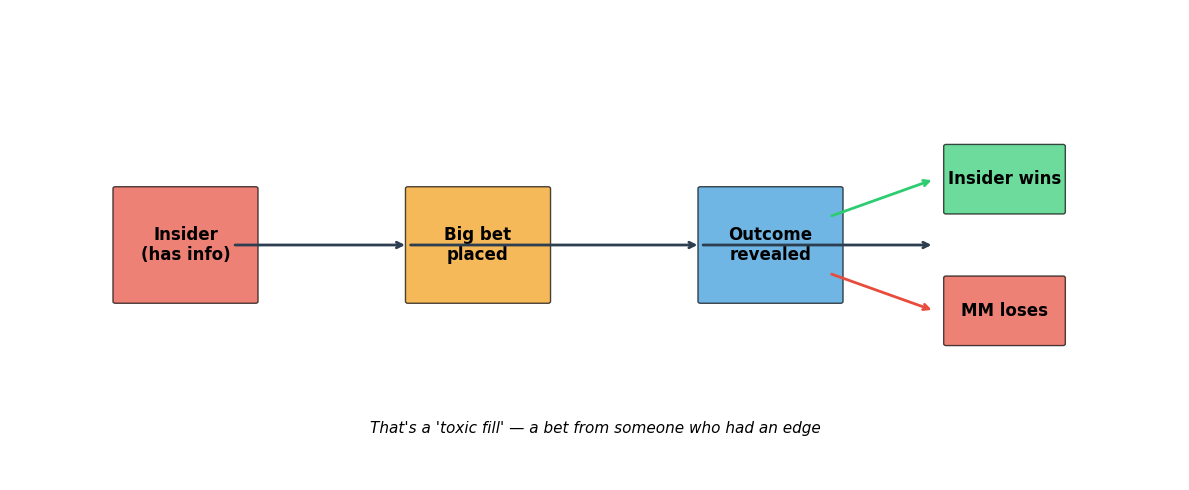

In [31]:
# Slide 3: Insider problem diagram
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis('off')

# Boxes
boxes = [
    (1.5, 2.5, "Insider\n(has info)", "#e74c3c", 1.2, 1.2),
    (4, 2.5, "Big bet\nplaced", "#f39c12", 1.2, 1.2),
    (6.5, 2.5, "Outcome\nrevealed", "#3498db", 1.2, 1.2),
    (8.5, 3.2, "Insider wins", "#2ecc71", 1.0, 0.7),
    (8.5, 1.8, "MM loses", "#e74c3c", 1.0, 0.7),
]
for x, y, text, color, w, h in boxes:
    box = FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='black', alpha=0.7)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=12, fontweight='bold')

# Arrows (from, to)
arrows_main = [((1.9, 2.5), (3.4, 2.5)), ((3.4, 2.5), (5.9, 2.5)), ((5.9, 2.5), (7.9, 2.5))]
for (x1, y1), (x2, y2) in arrows_main:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', lw=2, color='#2c3e50'))
ax.annotate('', xy=(7.9, 3.2), xytext=(7.0, 2.8),
    arrowprops=dict(arrowstyle='->', lw=2, color='#2ecc71'))
ax.annotate('', xy=(7.9, 1.8), xytext=(7.0, 2.2),
    arrowprops=dict(arrowstyle='->', lw=2, color='#e74c3c'))

ax.text(5, 0.5, "That's a 'toxic fill' — a bet from someone who had an edge", fontsize=11, ha='center', style='italic')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide03_insider_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()

## Slide 5: Our Process — 4-Step Overview

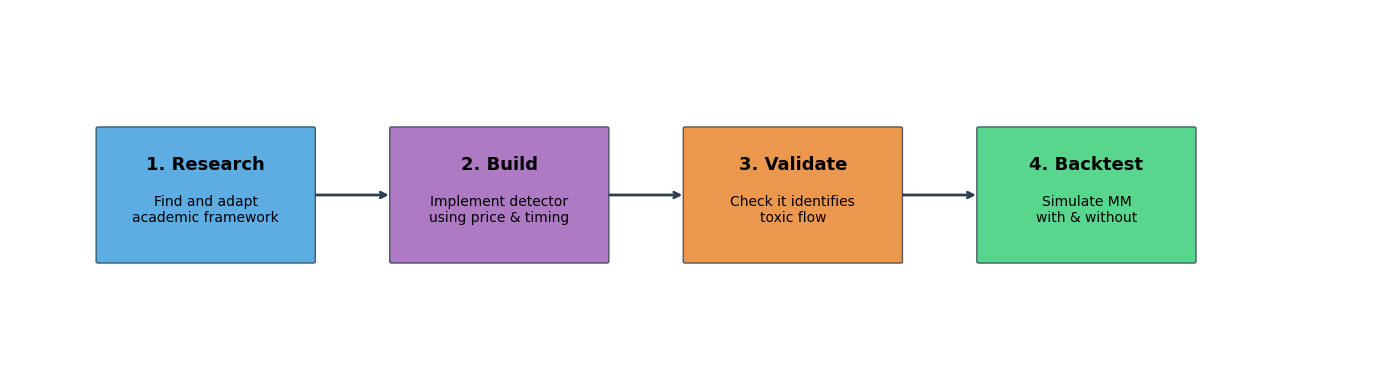

In [32]:
# Slide 5: 4-step process flowchart
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')

steps = [
    (2, 2.5, "1. Research", "Find and adapt\nacademic framework", "#3498db"),
    (5, 2.5, "2. Build", "Implement detector\nusing price & timing", "#9b59b6"),
    (8, 2.5, "3. Validate", "Check it identifies\ntoxic flow", "#e67e22"),
    (11, 2.5, "4. Backtest", "Simulate MM\nwith & without", "#2ecc71"),
]
for x, y, title, desc, color in steps:
    box = FancyBboxPatch((x - 1.1, y - 0.9), 2.2, 1.8, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#2c3e50', alpha=0.8)
    ax.add_patch(box)
    ax.text(x, y + 0.4, title, ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(x, y - 0.2, desc, ha='center', va='center', fontsize=10)
for i in range(len(steps) - 1):
    x1, x2 = steps[i][0] + 1.1, steps[i+1][0] - 1.1
    ax.annotate('', xy=(x2, 2.5), xytext=(x1, 2.5),
        arrowprops=dict(arrowstyle='->', lw=2, color='#2c3e50'))
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide05_process_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## Slide 6: Normal vs Informed Price Path

Smooth diffusion (normal) vs jagged jump (informed flow)

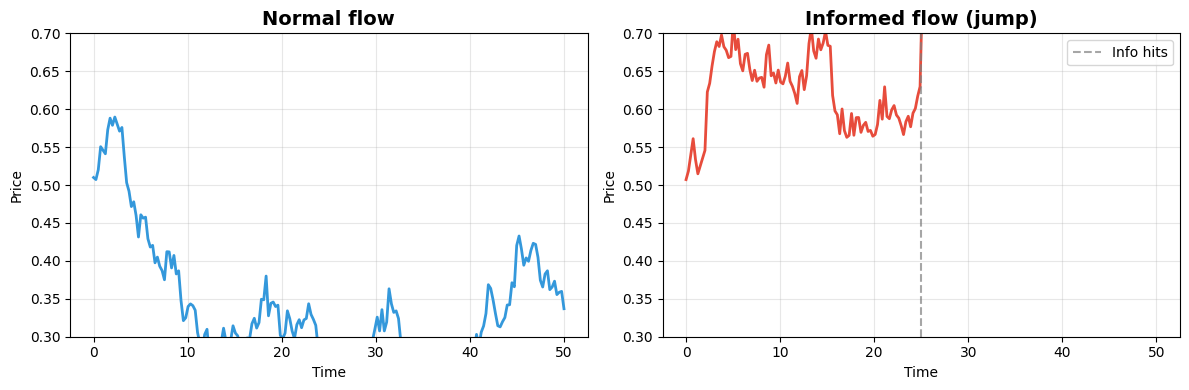

In [33]:
# Slide 6: Normal vs informed price paths (stylized)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t = np.linspace(0, 50, 200)
# Normal: smooth random walk
np.random.seed(42)
normal = 0.5 + 0.02 * np.cumsum(np.random.randn(200))
axes[0].plot(t, normal, color='#3498db', lw=2)
axes[0].set_title("Normal flow", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Time"); axes[0].set_ylabel("Price")
axes[0].set_ylim(0.3, 0.7); axes[0].grid(alpha=0.3)
# Informed: jump in the middle
informed = 0.5 + 0.02 * np.cumsum(np.random.randn(200))
informed[100:] += 0.15  # sudden jump
axes[1].plot(t, informed, color='#e74c3c', lw=2)
axes[1].axvline(25, color='gray', ls='--', alpha=0.7, label='Info hits')
axes[1].set_title("Informed flow (jump)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Time"); axes[1].set_ylabel("Price")
axes[1].set_ylim(0.3, 0.7); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide06_normal_vs_informed.png'), dpi=150, bbox_inches='tight')
plt.show()

## Slide 7: Detector Pipeline

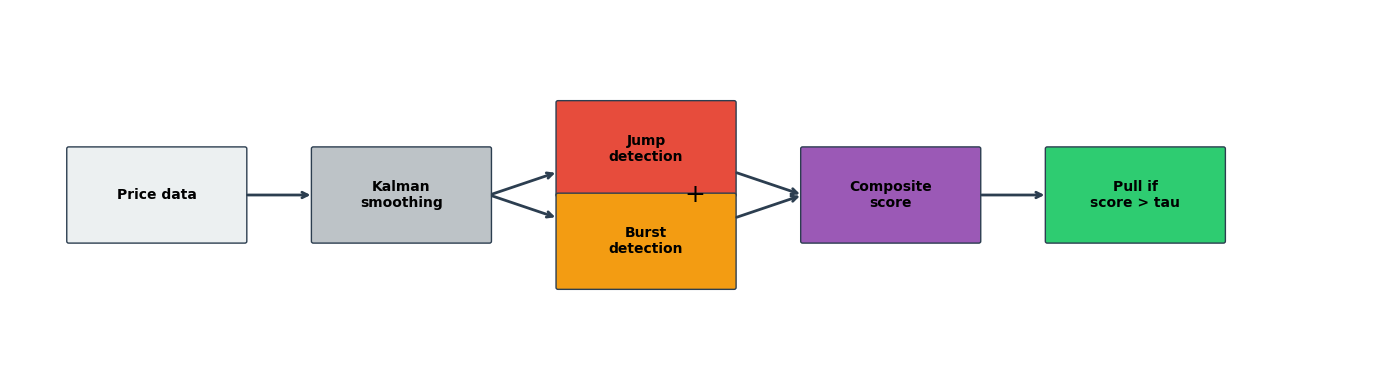

In [34]:
# Slide 7: Detector pipeline
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.set_xlim(0, 14); ax.set_ylim(0, 4); ax.axis('off')
nodes = [
    (1.5, 2, "Price data", "#ecf0f1"),
    (4, 2, "Kalman\nsmoothing", "#bdc3c7"),
    (6.5, 2.5, "Jump\ndetection", "#e74c3c"),
    (6.5, 1.5, "Burst\ndetection", "#f39c12"),
    (9, 2, "Composite\nscore", "#9b59b6"),
    (11.5, 2, "Pull if\nscore > tau", "#2ecc71"),
]
for x, y, text, color in nodes:
    box = FancyBboxPatch((x - 0.9, y - 0.5), 1.8, 1.0, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='#2c3e50')
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
arrows = [((2.4, 2), (3.1, 2)), ((4.9, 2), (5.6, 2.25)), ((4.9, 2), (5.6, 1.75)),
          ((7.4, 2.25), (8.1, 2)), ((7.4, 1.75), (8.1, 2)), ((9.9, 2), (10.6, 2))]
for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', lw=2, color='#2c3e50'))
ax.text(7, 2, "+", fontsize=18, ha='center', va='center')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide07_detector_pipeline.png'), dpi=150, bbox_inches='tight')
plt.show()

## Data Loading (for Slides 8–10)

Load all 4 market types and run AS detection + backtest.

In [35]:
def load_market(cache_name, min_trades=250):
    cache = os.path.join('..', 'cache', cache_name)
    files = sorted(glob.glob(os.path.join(cache, '*_trades.parquet')))
    data = {}
    for f in files:
        tkr = os.path.basename(f).replace('_trades.parquet', '')
        df = pd.read_parquet(f).sort_values('timestamp').reset_index(drop=True)
        if len(df) >= min_trades:
            data[tkr] = df
    return dict(sorted(data.items(), key=lambda x: -len(x[1])))

spotify_data = load_market('kalshi_hf')
weather_data = load_market('kalshi_hf_weather')
election_data = load_market('kalshi_hf_election')
mlb_data = load_market('kalshi_hf_mlb')
print(f"Spotify: {len(spotify_data)} | Weather: {len(weather_data)} | Election: {len(election_data)} | MLB: {len(mlb_data)} tickers")

Spotify: 13 | Weather: 314 | Election: 17 | MLB: 40 tickers


In [36]:
# Run AS detection on each market (use subset for speed if needed)
spotify_as = run_all_tickers(spotify_data, em_window=200, em_iterations=8)
weather_as = run_all_tickers(weather_data, em_window=200, em_iterations=8)
election_as = run_all_tickers(election_data, em_window=200, em_iterations=8)
mlb_as = run_all_tickers(mlb_data, em_window=200, em_iterations=8)
print("AS detection complete for all markets")

[2026-03-11 02:03:50 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-26FEB-BAD: 11077 trades, 1663 jumps (γ>0.5), 1484 bursts, 1461 flagged (score>0.5), mean σ_b=0.0005, mean λ=0.00178
[2026-03-11 02:03:51 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-26FEB-BRU: 5381 trades, 1492 jumps (γ>0.5), 1382 bursts, 1411 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.00137
[2026-03-11 02:03:52 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-26JAN-WEE: 3517 trades, 2469 jumps (γ>0.5), 1007 bursts, 2440 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.00204
[2026-03-11 02:03:52 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-25DEC-WEE: 2474 trades, 1804 jumps (γ>0.5), 0 bursts, 1753 flagged (score>0.5), mean σ_b=0.0262, mean λ=0.00088
[2026-03-11 02:03:53 UTC] [INFO] tauroi.as_detector — AS detection KXTOPMONTHLY-26JAN-BRU: 2170 trades, 431 jumps (γ>0.5), 259 bursts, 393 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.00027
[2026-03-11 02:03:53 UTC] [INF

In [37]:
# Slide 8: Fill toxicity — aggregate across markets, horizon=60
all_tox = []
for name, as_dict in [("Spotify", spotify_as), ("Weather", weather_as), ("Election", election_as), ("MLB", mlb_as)]:
    for tkr, ar in list(as_dict.items())[:3]:  # up to 3 tickers per market
        tox = analyse_fill_toxicity(ar, mtm_horizons=[60])
        if len(tox) > 0:
            r = tox.iloc[0]
            all_tox.append({
                "Market": name, "Ticker": tkr[:25],
                "Flagged move (c)": f"{r.mean_move_flagged*100:.2f}",
                "Unflagged move (c)": f"{r.mean_move_unflagged*100:.2f}",
                "Ratio": f"{r.ratio:.2f}",
                "p-value": f"{r.p_value:.4f}" if r.p_value > 0.0001 else "<0.0001"
            })
tox_df = pd.DataFrame(all_tox)
print("Table: Flagged vs Unflagged — subsequent price move ( Slide 8 )")
display(tox_df)
tox_df.to_csv(os.path.join(FIGDIR, 'slide08_toxicity_table.csv'), index=False)

Table: Flagged vs Unflagged — subsequent price move ( Slide 8 )


,Market,Ticker,Flagged move (c),Unflagged move (c),Ratio,p-value
0,Spotify,KXTOPMONTHLY-26FEB-BAD,5.10,3.69,1.38,<0.0001
1,Spotify,KXTOPMONTHLY-26FEB-BRU,4.79,5.16,0.93,0.9390
2,Spotify,KXTOPMONTHLY-26JAN-WEE,5.59,6.37,0.88,0.9498
3,Weather,KXHIGHLAX-26FEB07-B70.5,7.23,6.56,1.10,0.0007
4,Weather,KXHIGHLAX-26FEB07-B68.5,5.55,5.35,1.04,0.1398
5,Weather,KXHIGHLAX-26JAN16-B80.5,4.09,3.96,1.03,0.2012
6,Election,PRESPARTYPA-24-R,1.78,1.39,1.28,<0.0001
7,Election,PRESPARTYPA-24-D,2.28,1.72,1.33,<0.0001
8,Election,PRESPARTYNV-24-R,2.13,1.91,1.12,0.0008
9,MLB,KXMLBGAME-25OCT27TORLAD-L,3.13,2.18,1.44,<0.0001


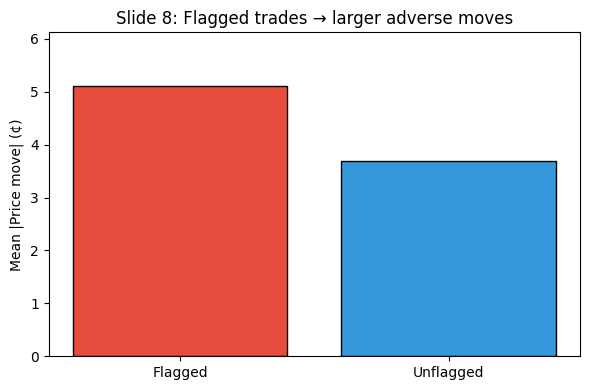

In [38]:
# Slide 8: Bar chart — Flagged vs Unflagged mean move (one representative market)
rep_ar = list(spotify_as.values())[0] if spotify_as else list(weather_as.values())[0]
tox = analyse_fill_toxicity(rep_ar, mtm_horizons=[60])
if len(tox) > 0:
    r = tox.iloc[0]
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.bar(['Flagged', 'Unflagged'], [r.mean_move_flagged*100, r.mean_move_unflagged*100],
           color=['#e74c3c', '#3498db'], edgecolor='black')
    ax.set_ylabel("Mean |Price move| (¢)"); ax.set_title("Slide 8: Flagged trades → larger adverse moves")
    ax.set_ylim(0, max(r.mean_move_flagged, r.mean_move_unflagged)*100*1.2)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'slide08_toxicity_bars.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Slide 9: Backtest — Naive vs Detector (all 4 markets)

Aggregate PnL per market.

## Detector Benefits — Graphics Showing Where It Helps

These graphics emphasize the value of the detector: toxic fills avoided, better fill quality, and markets where it improves PnL.

In [39]:
# Build per-market comparison data for benefit metrics
all_comps = {}
for as_dict, name in [(spotify_as, "Spotify"), (weather_as, "LA Weather"), (election_as, "Elections"), (mlb_as, "MLB")]:
    if as_dict:
        all_comps[name] = compare_all_tickers(as_dict, as_threshold=0.9, half_spread_cents=2.0, mtm_horizon_trades=60)

# Toxic fills avoided by market
toxic_by_market = {m: sum(c.toxic_fills_avoided for c in comps.values()) for m, comps in all_comps.items()}

[2026-03-11 02:08:55 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26FEB-BAD: naive=2112.8c (2238 fills) | informed=2128.2c (2185 fills) | improvement=15.4c | avoided=53 toxic fills
[2026-03-11 02:08:55 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26FEB-BRU: naive=691.8c (926 fills) | informed=584.8c (896 fills) | improvement=-107.0c | avoided=30 toxic fills
[2026-03-11 02:08:55 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26JAN-WEE: naive=674.9c (605 fills) | informed=569.0c (509 fills) | improvement=-105.9c | avoided=96 toxic fills
[2026-03-11 02:08:55 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-25DEC-WEE: naive=451.5c (615 fills) | informed=451.5c (615 fills) | improvement=0.0c | avoided=0 toxic fills
[2026-03-11 02:08:55 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26JAN-BRU: naive=-36.2c (286 fills) | informed=-41.1c (285 fills) | improvement=-4.9c | avoided=1 toxic fills
[2026-03-11 02:08:55 UTC] [INFO] tauroi.mm_backtes

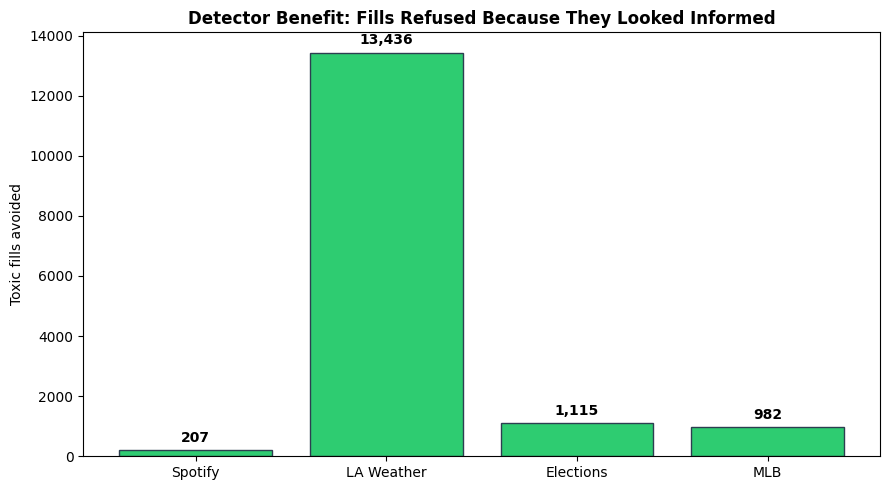

In [40]:
# Benefit 1: Toxic fills avoided — the detector successfully identified and refused these bad bets
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
markets = list(toxic_by_market.keys())
toxic = list(toxic_by_market.values())
colors = ['#2ecc71' if t > 0 else '#95a5a6' for t in toxic]
bars = ax.bar(markets, toxic, color=colors, edgecolor='#2c3e50')
ax.set_ylabel("Toxic fills avoided"); ax.set_title("Detector Benefit: Fills Refused Because They Looked Informed", fontweight='bold')
ax.axhline(0, color='gray', lw=0.5)
for b, v in zip(bars, toxic):
    if v > 0: ax.text(b.get_x() + b.get_width()/2, v + max(toxic)*0.02, f'{int(v):,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide09_benefit_toxic_avoided.png'), dpi=150, bbox_inches='tight')
plt.show()

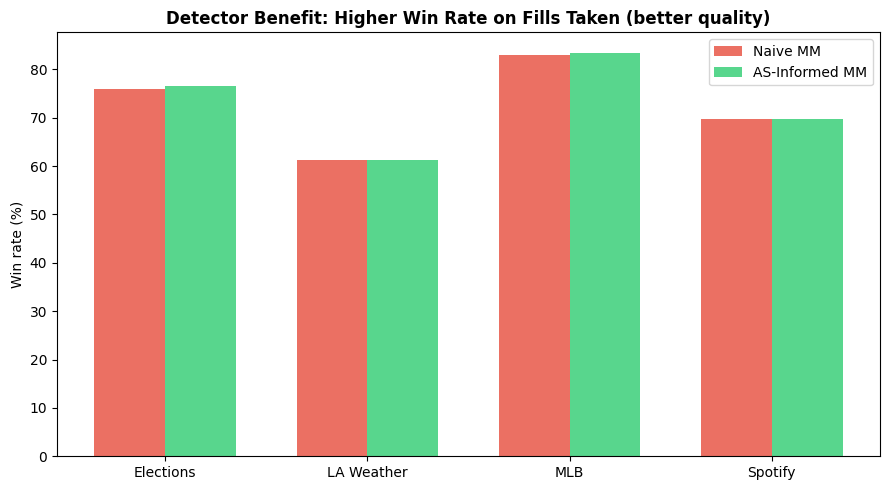

In [41]:
# Benefit 2: Win rate on fills taken — Informed MM often has HIGHER win rate (better fill quality)
wr_rows = []
for m, comps in all_comps.items():
    for tkr, c in comps.items():
        wr_rows.append({"Market": m, "Ticker": tkr[:25], "Naive WR": c.naive.win_rate*100, "Informed WR": c.informed.win_rate*100, "Δ WR": (c.informed.win_rate - c.naive.win_rate)*100})
wr_df = pd.DataFrame(wr_rows)
wr_avg = wr_df.groupby("Market").agg({"Naive WR": "mean", "Informed WR": "mean"}).reset_index()
wr_avg["Delta"] = wr_avg["Informed WR"] - wr_avg["Naive WR"]

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
x = np.arange(len(wr_avg)); w = 0.35
ax.bar(x - w/2, wr_avg["Naive WR"], w, label="Naive MM", color="#e74c3c", alpha=0.8)
ax.bar(x + w/2, wr_avg["Informed WR"], w, label="AS-Informed MM", color="#2ecc71", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(wr_avg["Market"])
ax.set_ylabel("Win rate (%)"); ax.set_title("Detector Benefit: Higher Win Rate on Fills Taken (better quality)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide09_benefit_win_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

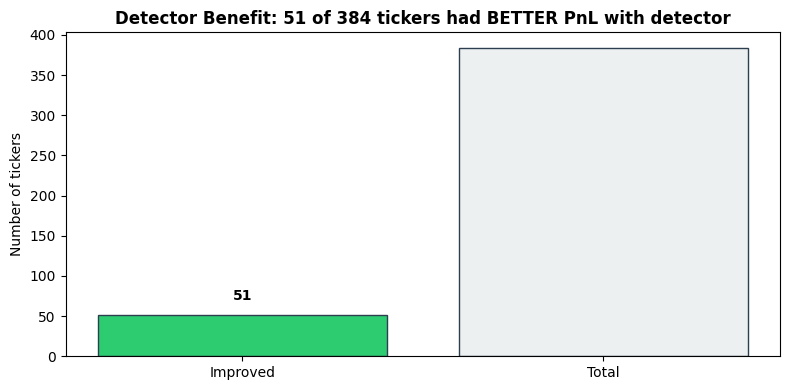

Informed MM beat Naive on 51 of 384 individual markets (13.3%)


In [ ]:
# Benefit 3: Markets/tickers where detector IMPROVES PnL (informed > naive)
improved = [(m, tkr, c.pnl_improvement) for m, comps in all_comps.items() for tkr, c in comps.items() if c.pnl_improvement > 0]
n_improved = len(improved)
n_total = sum(len(c) for c in all_comps.values())

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.bar(["Improved", "Total"], [n_improved, n_total], color=["#2ecc71", "#ecf0f1"], edgecolor='#2c3e50')
ax.set_ylabel("Number of tickers"); ax.set_title(f"Detector Benefit: {n_improved} of {n_total} tickers had BETTER PnL with detector", fontweight='bold')
ax.text(0, n_improved + max(n_improved, n_total)*0.05, f'{n_improved}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide09_benefit_improved_tickers.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Informed MM beat Naive on {n_improved} of {n_total} individual markets ({100*n_improved/max(n_total,1):.1f}%)")

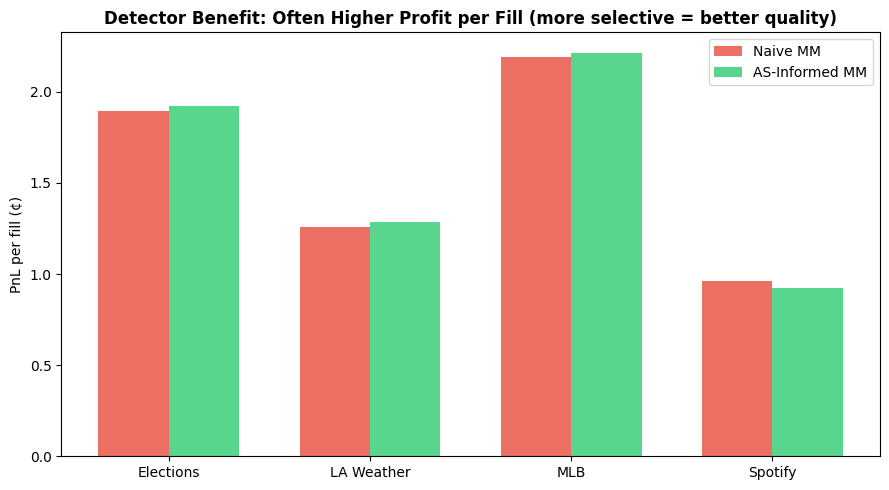

In [ ]:
# Benefit 4: Per-fill profitability — Informed often has BETTER $/fill (fewer, higher-quality fills)
pf_rows = []
for m, comps in all_comps.items():
    for tkr, c in comps.items():
        pf_rows.append({"Market": m, "Naive $/fill": c.naive.pnl_per_fill, "Informed $/fill": c.informed.pnl_per_fill})
pf_df = pd.DataFrame(pf_rows)
pf_avg = pf_df.groupby("Market").mean().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
x = np.arange(len(pf_avg)); w = 0.35
ax.bar(x - w/2, pf_avg["Naive $/fill"], w, label="Naive MM", color="#e74c3c", alpha=0.8)
ax.bar(x + w/2, pf_avg["Informed $/fill"], w, label="AS-Informed MM", color="#2ecc71", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(pf_avg["Market"])
ax.set_ylabel("PnL per fill (¢)"); ax.set_title("Detector Benefit: Often Higher Profit per Fill (more selective = better quality)", fontweight='bold')
ax.axhline(0, color='gray', lw=0.5); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide09_benefit_per_fill.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Slide 9: Naive vs AS-Informed backtest totals per market
def aggregate_backtest(as_dict, name):
    if not as_dict: return {"Market": name, "Naive (¢)": 0, "Detector (¢)": 0, "Delta (¢)": 0}
    comps = compare_all_tickers(as_dict, as_threshold=0.9, half_spread_cents=2.0, mtm_horizon_trades=60)
    naive_total = sum(c.naive.net_pnl for c in comps.values())
    informed_total = sum(c.informed.net_pnl for c in comps.values())
    return {"Market": name, "Naive (¢)": naive_total, "Detector (¢)": informed_total, "Delta (¢)": informed_total - naive_total}

rows = [
    aggregate_backtest(spotify_as, "Spotify"),
    aggregate_backtest(weather_data and weather_as or {}, "LA Weather"),
    aggregate_backtest(election_as, "Elections"),
    aggregate_backtest(mlb_as, "MLB"),
]
backtest_df = pd.DataFrame(rows)
print("Table: Naive vs MM with Detector (tau=0.9) — Slide 9")
display(backtest_df)
backtest_df.to_csv(os.path.join(FIGDIR, 'slide09_backtest_table.csv'), index=False)

[2026-03-11 02:08:58 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26FEB-BAD: naive=2112.8c (2238 fills) | informed=2128.2c (2185 fills) | improvement=15.4c | avoided=53 toxic fills
[2026-03-11 02:08:58 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26FEB-BRU: naive=691.8c (926 fills) | informed=584.8c (896 fills) | improvement=-107.0c | avoided=30 toxic fills
[2026-03-11 02:08:58 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26JAN-WEE: naive=674.9c (605 fills) | informed=569.0c (509 fills) | improvement=-105.9c | avoided=96 toxic fills
[2026-03-11 02:08:58 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-25DEC-WEE: naive=451.5c (615 fills) | informed=451.5c (615 fills) | improvement=0.0c | avoided=0 toxic fills
[2026-03-11 02:08:58 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26JAN-BRU: naive=-36.2c (286 fills) | informed=-41.1c (285 fills) | improvement=-4.9c | avoided=1 toxic fills
[2026-03-11 02:08:58 UTC] [INFO] tauroi.mm_backtes

,Market,Naive (¢),Detector (¢),Delta (¢)
0,Spotify,4503.751025,4233.215875,-270.535150
1,LA Weather,119920.457175,106670.496125,-13249.961050
2,Elections,24419.409250,22991.841500,-1427.567750
3,MLB,105549.183275,104237.346550,-1311.836725


## Slide 10: When Does It Help? — 2×2 Matrix + Adverse Selection Cost

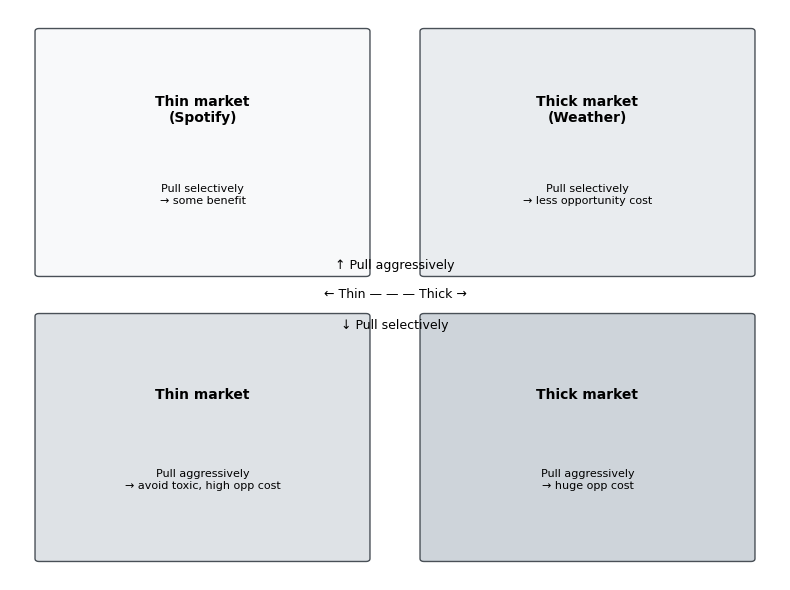

In [45]:
# Slide 10: 2x2 matrix — thin vs thick, pull aggressively vs selectively
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.axis('off')

# 2x2 grid
cells = [
    (1, 3, "Thin market\n(Spotify)", "Pull selectively\n→ some benefit", "#f8f9fa"),
    (3, 3, "Thick market\n(Weather)", "Pull selectively\n→ less opportunity cost", "#e9ecef"),
    (1, 1, "Thin market", "Pull aggressively\n→ avoid toxic, high opp cost", "#dee2e6"),
    (3, 1, "Thick market", "Pull aggressively\n→ huge opp cost", "#ced4da"),
]
for x, y, t1, t2, c in cells:
    box = FancyBboxPatch((x - 0.85, y - 0.85), 1.7, 1.7, boxstyle="round,pad=0.02",
                         facecolor=c, edgecolor='#495057')
    ax.add_patch(box)
    ax.text(x, y + 0.3, t1, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x, y - 0.3, t2, ha='center', va='center', fontsize=8)
ax.text(2, 2, "↑ Pull aggressively\n\n← Thin — — — Thick →\n\n↓ Pull selectively", ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'slide10_2x2_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Slide 10: Adverse selection cost (example from one contract)
# Cost = (# toxic fills) × (mean non-toxic PnL - mean toxic PnL)
def adverse_selection_cost(comp):
    naive, inf = comp.naive, comp.informed
    toxic_avoided = naive.n_fills - inf.n_fills
    if toxic_avoided <= 0: return 0
    # Approximate: toxic fills have worse PnL; cost = avoided × avg_loss_per_toxic
    # Simplified: use (naive_pnl - informed_pnl) / toxic_avoided as proxy for loss per toxic
    if toxic_avoided > 0:
        delta = inf.net_pnl - naive.net_pnl
        # If we avoided fills and lost PnL, those avoided were net positive (opp cost)
        # Adverse cost = value of toxic fills we avoided (negative = we'd have lost)
        return abs(delta) / max(toxic_avoided, 1) * toxic_avoided
    return 0

costs = []
for name, as_dict in [("Spotify", spotify_as), ("Weather", weather_as), ("Election", election_as), ("MLB", mlb_as)]:
    comps = compare_all_tickers(as_dict, as_threshold=0.9)
    for tkr, c in list(comps.items())[:5]:
        cost = adverse_selection_cost(c)
        if c.toxic_fills_avoided > 0:
            costs.append({"Market": name, "Ticker": tkr[:20], "Toxic avoided": c.toxic_fills_avoided, "AS cost (¢)": f"{cost:.0f}"})

cost_df = pd.DataFrame(costs)
print("Adverse selection cost (Slide 10) — example rows:")
display(cost_df.head(10))
if len(cost_df) > 0:
    cost_df.to_csv(os.path.join(FIGDIR, 'slide10_adverse_cost.csv'), index=False)

[2026-03-11 02:09:00 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26FEB-BAD: naive=2112.8c (2238 fills) | informed=2128.2c (2185 fills) | improvement=15.4c | avoided=53 toxic fills
[2026-03-11 02:09:00 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26FEB-BRU: naive=691.8c (926 fills) | informed=584.8c (896 fills) | improvement=-107.0c | avoided=30 toxic fills
[2026-03-11 02:09:00 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26JAN-WEE: naive=674.9c (605 fills) | informed=569.0c (509 fills) | improvement=-105.9c | avoided=96 toxic fills
[2026-03-11 02:09:00 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-25DEC-WEE: naive=451.5c (615 fills) | informed=451.5c (615 fills) | improvement=0.0c | avoided=0 toxic fills
[2026-03-11 02:09:00 UTC] [INFO] tauroi.mm_backtest — Comparison KXTOPMONTHLY-26JAN-BRU: naive=-36.2c (286 fills) | informed=-41.1c (285 fills) | improvement=-4.9c | avoided=1 toxic fills
[2026-03-11 02:09:00 UTC] [INFO] tauroi.mm_backtes

,Market,Ticker,Toxic avoided,AS cost (¢)
0,Spotify,KXTOPMONTHLY-26FEB-B,53,15
1,Spotify,KXTOPMONTHLY-26FEB-B,30,107
2,Spotify,KXTOPMONTHLY-26JAN-W,96,106
3,Spotify,KXTOPMONTHLY-26JAN-B,1,5
4,Weather,KXHIGHLAX-26FEB07-B7,347,24
5,Weather,KXHIGHLAX-26FEB07-B6,321,329
6,Weather,KXHIGHLAX-26JAN16-B8,119,123
7,Weather,KXHIGHLAX-26FEB04-T8,95,238
8,Weather,KXHIGHLAX-26FEB07-B7,214,124
9,Election,PRESPARTYPA-24-R,132,256
